# Lab 09 - NLP Text Classification

In this lab, we practise text preprocessing and visualisation, then build supervised models for a legal text classification task.

## Dataset: https://www.kaggle.com/datasets/amohankumar/legal-text-classification-dataset

The dataset used here is `legal_text_classification.csv`, a labelled legal text dataset with the following columns:

- `case_id`: unique case identifier
- `case_outcome`: target label for classification
- `case_title`: case name/title
- `case_text`: legal text excerpt

The goal is to predict `case_outcome` from the case title and legal text.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

SEED = 42
DATA_PATH = Path("legal_text_classification.csv")

pd.set_option("display.max_colwidth", 120)

In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

print("\nMissing values:")
display(df.isna().sum())

print("\nClass distribution:")
display(df["case_outcome"].value_counts())

Dataset shape: (24985, 4)


,case_id,case_outcome,case_title,case_text
0,Case1,cited,Alpine Hardwood (Aust) Pty Ltd v Hardys Pty Ltd (No 2) [2002] FCA 224 ; (2002) 190 ALR 121,Ordinarily that discretion will be exercised so that costs follow the event and are awarded on a party and party bas...
1,Case2,cited,Black v Lipovac [1998] FCA 699 ; (1998) 217 ALR 386,The general principles governing the exercise of the discretion to award indemnity costs after rejection by an unsuc...
2,Case3,cited,Colgate Palmolive Co v Cussons Pty Ltd (1993) 47 FCR 225,Ordinarily that discretion will be exercised so that costs follow the event and are awarded on a party and party bas...
3,Case4,cited,Dais Studio Pty Ltd v Bullett Creative Pty Ltd [2008] FCA 42,The general principles governing the exercise of the discretion to award indemnity costs after rejection by an unsuc...
4,Case5,cited,Dr Martens Australia Pty Ltd v Figgins Holdings Pty Ltd (No 2) [2000] FCA 602,The preceding general principles inform the exercise of the discretion. That discretion is not to be fettered by tra...



Missing values:


case_id           0
case_outcome      0
case_title        0
case_text       176
dtype: int64


Class distribution:


case_outcome
cited            12219
referred to       4384
applied           2448
followed          2256
considered        1712
discussed         1024
distinguished      608
related            113
affirmed           113
approved           108
Name: count, dtype: int64

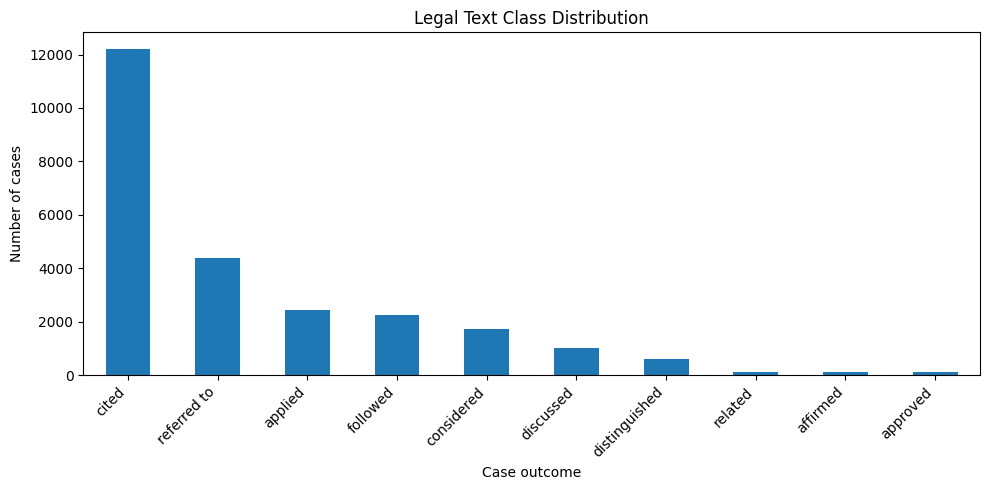

In [3]:
label_counts = df["case_outcome"].value_counts()

plt.figure(figsize=(10, 5))
label_counts.plot(kind="bar")
plt.title("Legal Text Class Distribution")
plt.xlabel("Case outcome")
plt.ylabel("Number of cases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [4]:
def clean_text(text: str) -> str:
    """Basic normalisation before TF-IDF tokenisation."""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


clean_df = df.dropna(subset=["case_text", "case_outcome"]).copy()
clean_df["combined_text"] = clean_df["case_title"].fillna("") + " " + clean_df["case_text"].fillna("")
clean_df["clean_text"] = clean_df["combined_text"].apply(clean_text)

print("Rows before cleaning:", len(df))
print("Rows after dropping missing text/labels:", len(clean_df))

display(clean_df[["case_outcome", "clean_text"]].head())

Rows before cleaning: 24985
Rows after dropping missing text/labels: 24809


,case_outcome,clean_text
0,cited,alpine hardwood aust pty ltd v hardys pty ltd no 2 2002 fca 224 2002 190 alr 121 ordinarily that discretion will be ...
1,cited,black v lipovac 1998 fca 699 1998 217 alr 386 the general principles governing the exercise of the discretion to awa...
2,cited,colgate palmolive co v cussons pty ltd 1993 47 fcr 225 ordinarily that discretion will be exercised so that costs fo...
3,cited,dais studio pty ltd v bullett creative pty ltd 2008 fca 42 the general principles governing the exercise of the disc...
4,cited,dr martens australia pty ltd v figgins holdings pty ltd no 2 2000 fca 602 the preceding general principles inform th...


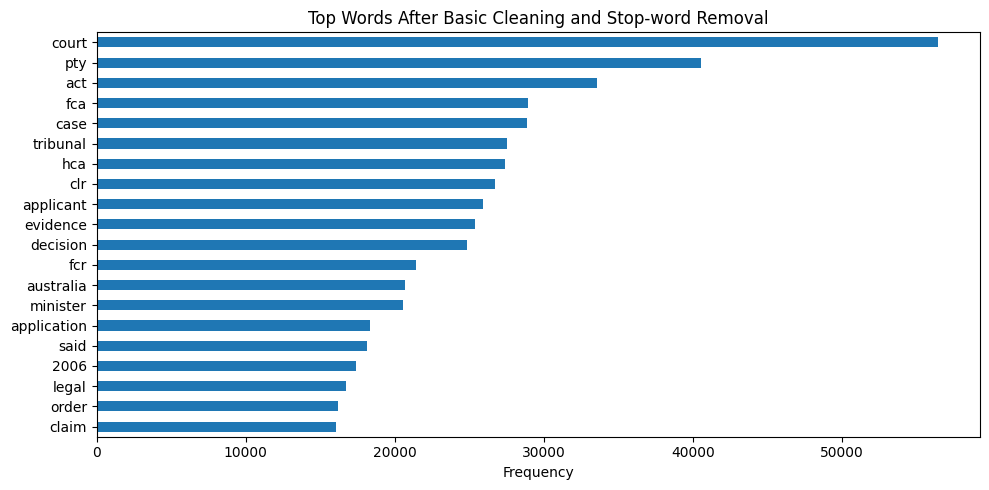

In [5]:
def get_top_words(texts, n=20):
    words = " ".join(texts).split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS and len(word) > 2]
    return pd.Series(words).value_counts().head(n)


top_words = get_top_words(clean_df["clean_text"], n=20)

plt.figure(figsize=(10, 5))
top_words.sort_values().plot(kind="barh")
plt.title("Top Words After Basic Cleaning and Stop-word Removal")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

In [6]:
X = clean_df["clean_text"]
y = clean_df["case_outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Number of classes:", y.nunique())

Training rows: 19847
Testing rows: 4962
Number of classes: 10


In [7]:
def make_tfidf_vectorizer():
    return TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.90,
        max_features=50_000,
    )


models = {
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.3),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=SEED, max_iter=5000),
}

trained_models = {}
results = []

for model_name, classifier in models.items():
    pipeline = Pipeline([
        ("tfidf", make_tfidf_vectorizer()),
        ("classifier", classifier),
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0,
    )

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
    })

    trained_models[model_name] = {
        "pipeline": pipeline,
        "predictions": y_pred,
    }

results_df = pd.DataFrame(results).sort_values("weighted_f1", ascending=False)
display(results_df.round(4))

,model,accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1
1,Linear SVM,0.5621,0.5752,0.5621,0.5675,0.4072,0.4763,0.4343
0,Multinomial Naive Bayes,0.5266,0.5222,0.5266,0.4146,0.3668,0.1458,0.1488


In [8]:
best_model_name = results_df.iloc[0]["model"]
best_predictions = trained_models[best_model_name]["predictions"]

print(f"Best model by weighted F1: {best_model_name}\n")
print(classification_report(y_test, best_predictions, zero_division=0))

Best model by weighted F1: Linear SVM

               precision    recall  f1-score   support

     affirmed       0.52      0.71      0.60        21
      applied       0.36      0.36      0.36       488
     approved       0.20      0.38      0.26        21
        cited       0.73      0.69      0.71      2422
   considered       0.35      0.40      0.38       340
    discussed       0.32      0.43      0.37       204
distinguished       0.33      0.37      0.35       121
     followed       0.38      0.37      0.37       450
  referred to       0.55      0.55      0.55       873
      related       0.33      0.50      0.40        22

     accuracy                           0.56      4962
    macro avg       0.41      0.48      0.43      4962
 weighted avg       0.58      0.56      0.57      4962



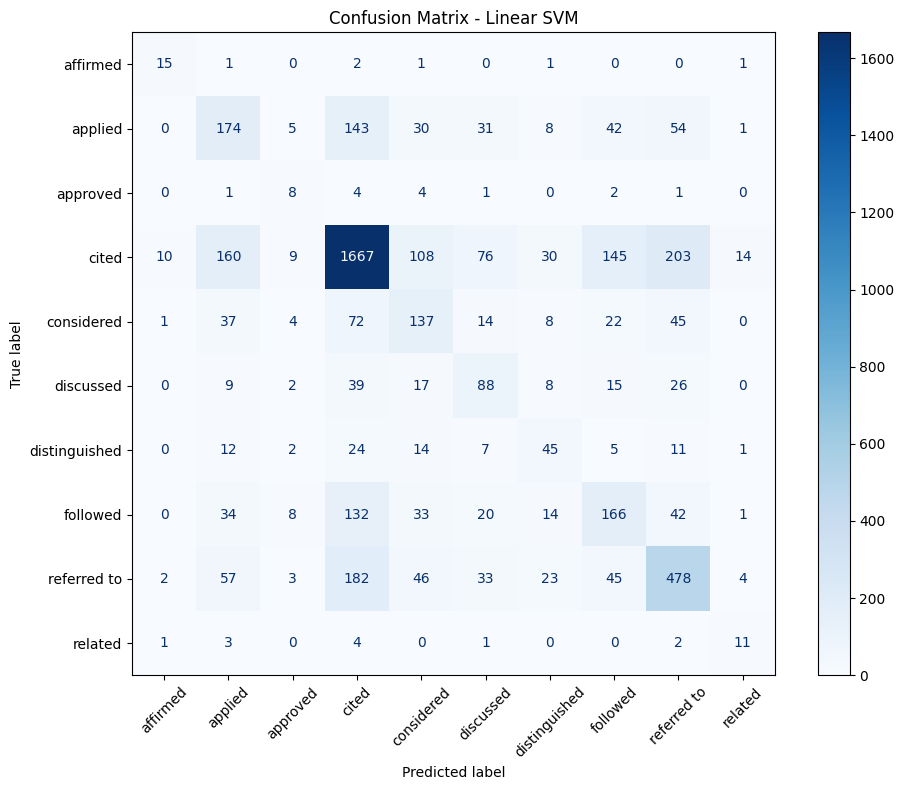

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax,
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

## 6. Discussion

The dataset is strongly imbalanced. In a local run, the cleaned dataset contained 24,809 usable rows after removing 176 records with missing text. The most common label was `cited`, while labels such as `approved`, `affirmed`, and `related` had just over 100 examples each.

The Multinomial Naive Bayes model is included as a simple text-classification baseline. It trains quickly and often performs reasonably well with TF-IDF features, but it assumes features are conditionally independent and tends to favour common classes in imbalanced datasets.

The Linear SVM is a good choice for this problem because TF-IDF creates a sparse, high-dimensional feature matrix. Linear SVMs usually work well in this setting, and the balanced class weighting helps the model pay more attention to minority classes.

On this dataset, the Linear SVM produced the best result in the benchmark run:

- Multinomial Naive Bayes: accuracy 0.5266, weighted F1 0.4146, macro F1 0.1488
- Linear SVM: accuracy 0.5621, weighted F1 0.5675, macro F1 0.4343

The SVM improved both weighted F1 and macro F1, meaning it handled the smaller classes better than Naive Bayes. However, the overall scores are moderate because many legal outcome labels are semantically similar and the class distribution is uneven. Future improvements could be implemented are legal-domain preprocessing, hyperparameter tuning, class resampling, or transformer-based legal language models.